# NutriMatch EDA

This notebook explores the cleaned Food.com dataset stored in `Final/Data/Pure_Data`.

Main goals:
- understand recipe metadata and nutrition distributions
- inspect user-item interaction patterns for recommendation modeling
- generate report-ready figures in `Final/EDA/Figures`


In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 7)
plt.rcParams["axes.titlesize"] = 18
plt.rcParams["axes.labelsize"] = 13
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 120)

cwd = Path.cwd().resolve()
workspace_root = next((path for path in [cwd, *cwd.parents] if (path / "Final").exists()), None)
if workspace_root is None:
    raise FileNotFoundError("Could not locate workspace root with Final directory")

pure_data_dir = workspace_root / "Final" / "Data" / "Pure_Data"
figure_dir = workspace_root / "Final" / "EDA" / "Figures"
figure_dir.mkdir(parents=True, exist_ok=True)

recipes = pd.read_csv(pure_data_dir / "recipes_clean.csv")
interactions = pd.read_csv(pure_data_dir / "interactions_filtered.csv")
recipe_model = pd.read_csv(pure_data_dir / "recipe_model_table.csv")

recipes["tags_list"] = recipes["tags_list"].map(json.loads)
recipes["ingredients_list"] = recipes["ingredients_list"].map(json.loads)
recipes["submitted"] = pd.to_datetime(recipes["submitted"], errors="coerce")
interactions["date"] = pd.to_datetime(interactions["date"], errors="coerce")

recipes.shape, interactions.shape, recipe_model.shape

((230543, 27), (535047, 5), (230543, 30))

## Dataset Overview

In [2]:
n_users = interactions["user_id"].nunique()
n_items = interactions["recipe_id"].nunique()
n_interactions = len(interactions)
matrix_sparsity = 1 - (n_interactions / (n_users * n_items))

overview = pd.DataFrame(
    {
        "metric": [
            "recipes",
            "users",
            "recipes with filtered interactions",
            "filtered interactions",
            "matrix sparsity",
            "median recipe time (minutes)",
            "median ingredient count",
            "share of quick recipes (<= 30 min)",
        ],
        "value": [
            len(recipes),
            n_users,
            n_items,
            n_interactions,
            round(matrix_sparsity, 6),
            int(recipes["minutes"].median()),
            int(recipes["n_ingredients"].median()),
            round(float(recipes["quick_recipe"].mean()), 4),
        ],
    }
)

overview

,metric,value
0,recipes,230543.000000
1,users,17034.000000
2,recipes with filtered interactions,40027.000000
3,filtered interactions,535047.000000
4,matrix sparsity,0.999215
5,median recipe time (minutes),40.000000
6,median ingredient count,9.000000
7,share of quick recipes (<= 30 min),0.424900


In [3]:
data_quality = pd.DataFrame(
    {
        "column": ["description", "submitted", "calories", "protein_pdv"],
        "missing_or_blank_rate": [
            round(float((recipes["description"].fillna("").str.strip() == "").mean()), 4),
            round(float(recipes["submitted"].isna().mean()), 4),
            round(float(recipes["calories"].isna().mean()), 4),
            round(float(recipes["protein_pdv"].isna().mean()), 4),
        ],
    }
)

data_quality

,column,missing_or_blank_rate
0,description,0.0187
1,submitted,0.0000
2,calories,0.0000
3,protein_pdv,0.0000


## Recipe Metadata Distributions

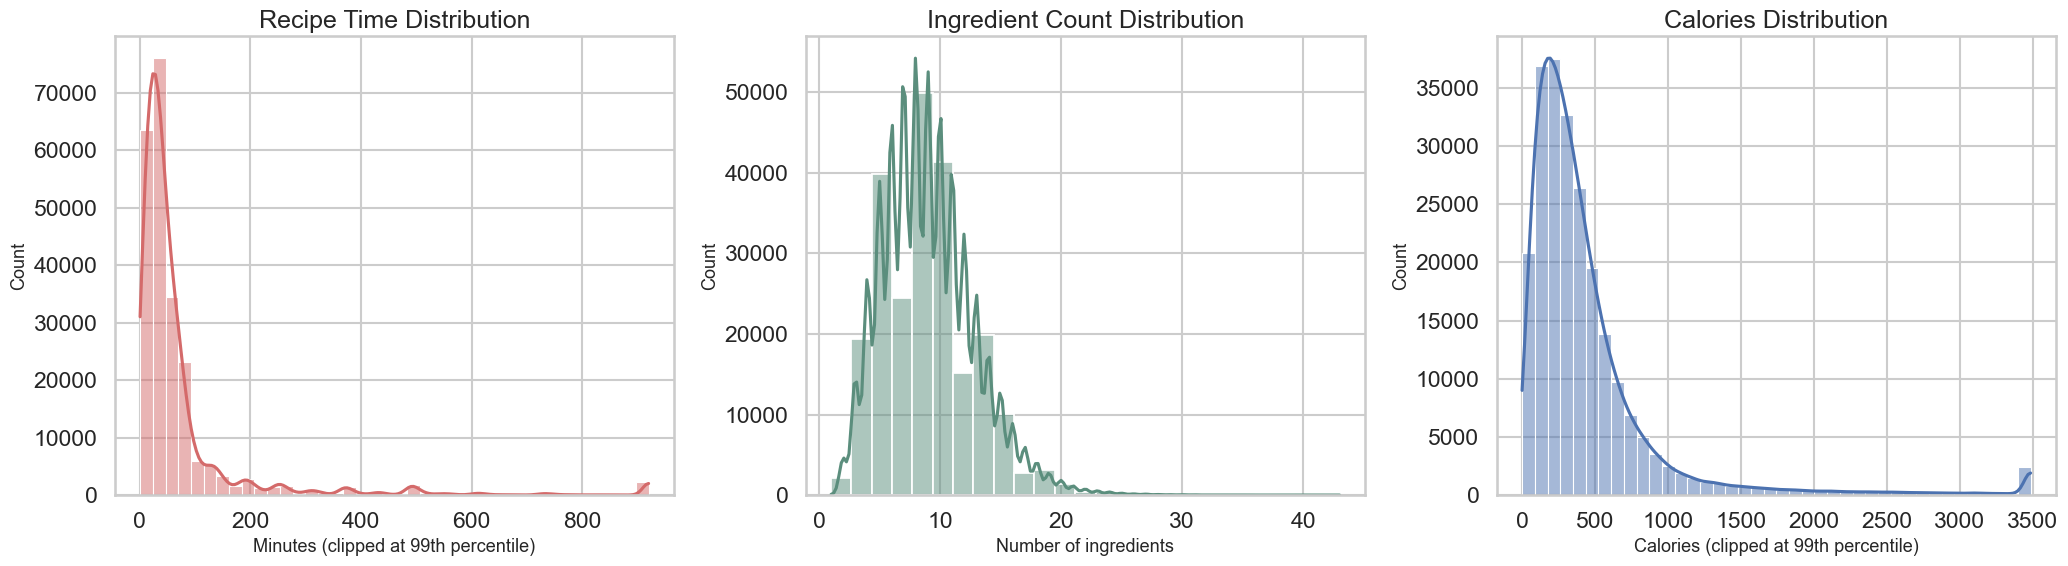

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(21, 6))

minutes_clip = recipes["minutes"].clip(upper=recipes["minutes"].quantile(0.99))
calories_clip = recipes["calories"].clip(upper=recipes["calories"].quantile(0.99))

sns.histplot(minutes_clip, bins=40, kde=True, ax=axes[0], color="#d46a6a")
axes[0].set_title("Recipe Time Distribution")
axes[0].set_xlabel("Minutes (clipped at 99th percentile)")

sns.histplot(recipes["n_ingredients"], bins=25, kde=True, ax=axes[1], color="#5b8e7d")
axes[1].set_title("Ingredient Count Distribution")
axes[1].set_xlabel("Number of ingredients")

sns.histplot(calories_clip, bins=40, kde=True, ax=axes[2], color="#4c72b0")
axes[2].set_title("Calories Distribution")
axes[2].set_xlabel("Calories (clipped at 99th percentile)")

fig.tight_layout()
fig.savefig(figure_dir / "recipe_metadata_distributions.png", dpi=200, bbox_inches="tight")
plt.show()

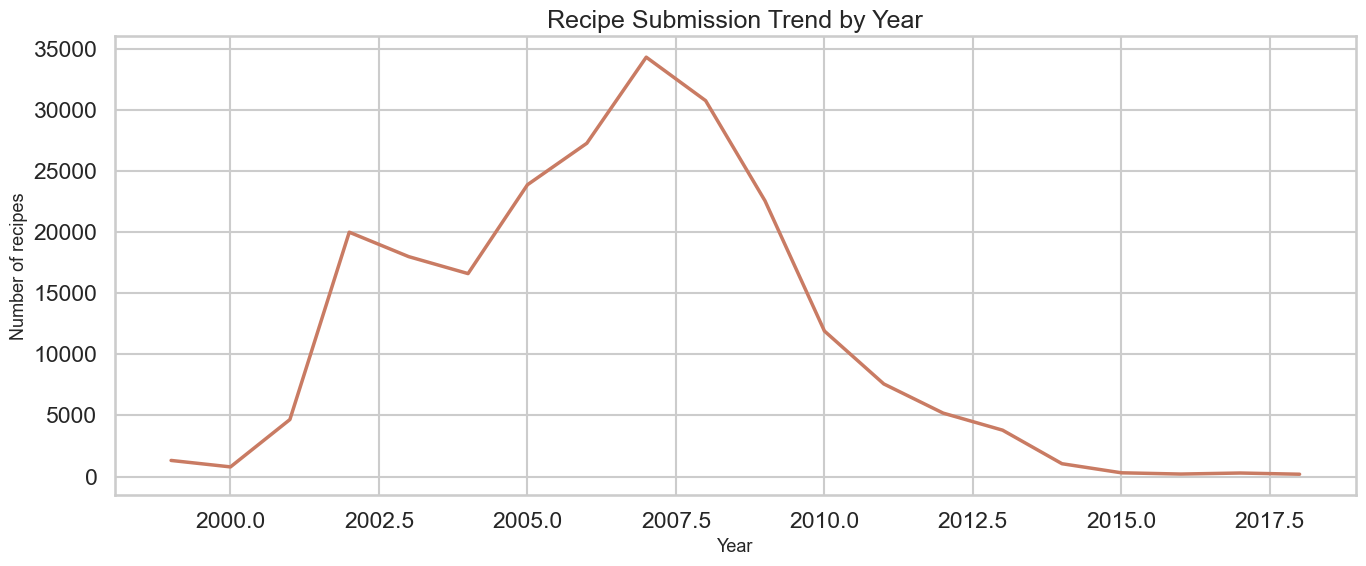

In [5]:
submission_trend = recipes.groupby("submitted_year").size().reset_index(name="recipe_count")
submission_trend = submission_trend.dropna().sort_values("submitted_year")

plt.figure(figsize=(14, 6))
sns.lineplot(data=submission_trend, x="submitted_year", y="recipe_count", linewidth=2.5, color="#c97b63")
plt.title("Recipe Submission Trend by Year")
plt.xlabel("Year")
plt.ylabel("Number of recipes")
plt.tight_layout()
plt.savefig(figure_dir / "recipe_submission_trend.png", dpi=200, bbox_inches="tight")
plt.show()

## Interaction Patterns

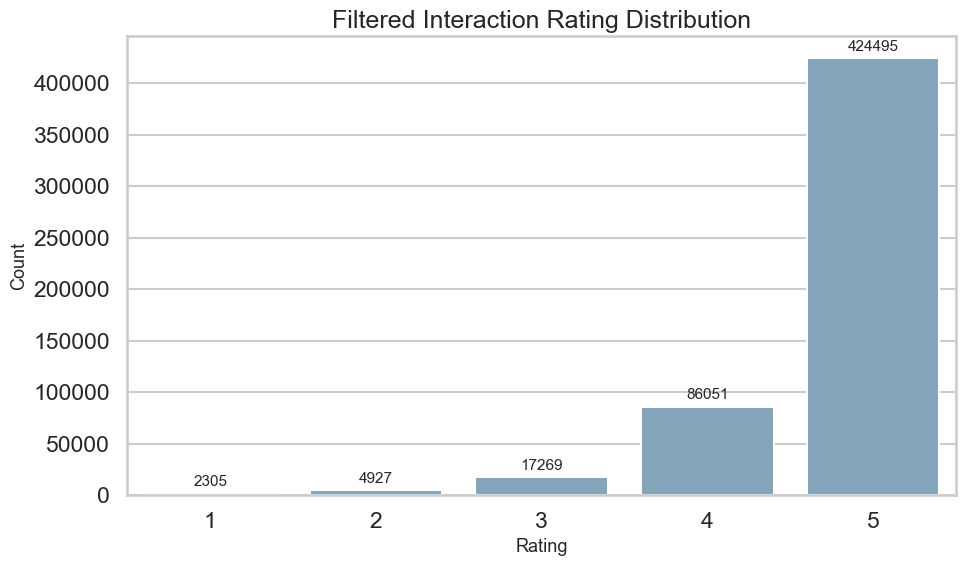

,rating,count
0,1,2305
1,2,4927
2,3,17269
3,4,86051
4,5,424495


In [6]:
rating_dist = interactions["rating"].value_counts().sort_index().rename_axis("rating").reset_index(name="count")

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=rating_dist, x="rating", y="count", color="#7aa6c2")
ax.bar_label(ax.containers[0], padding=3, fontsize=11)
plt.title("Filtered Interaction Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(figure_dir / "rating_distribution.png", dpi=200, bbox_inches="tight")
plt.show()

rating_dist

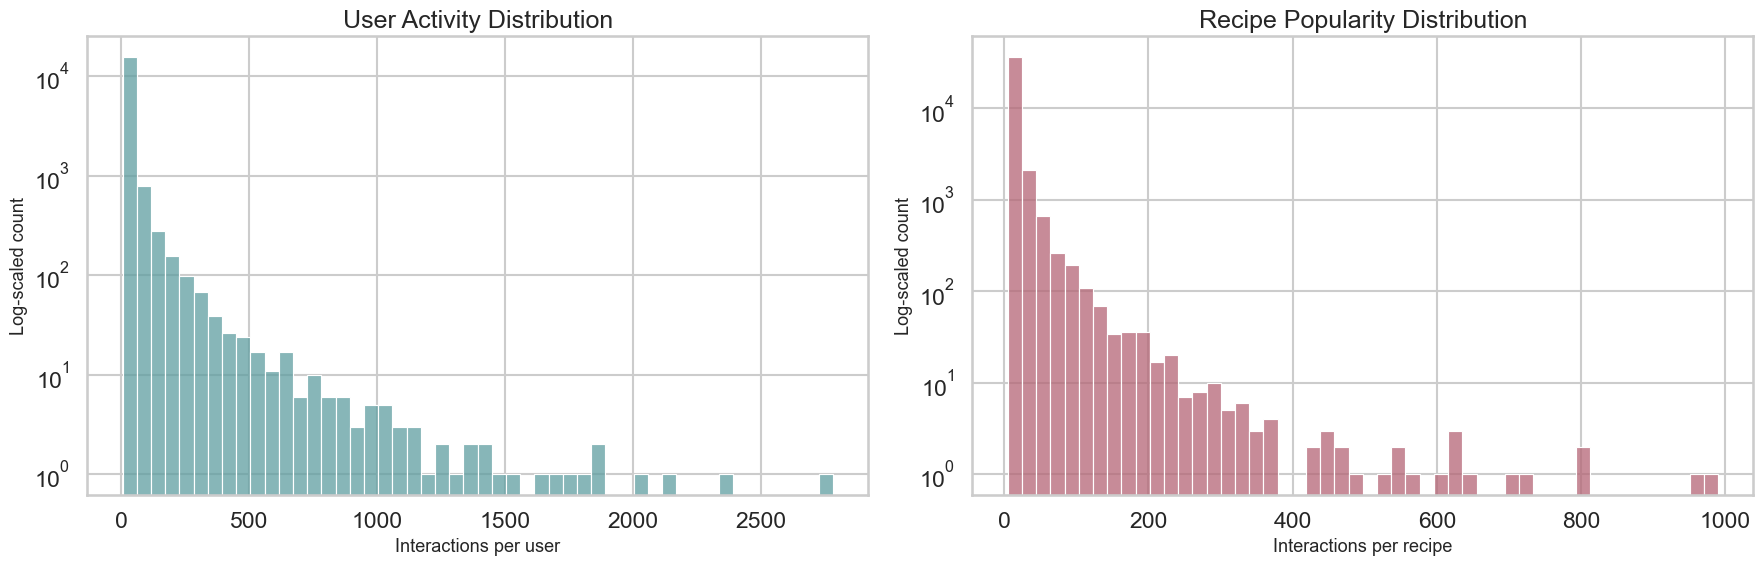

,quantile,user_interactions,recipe_interactions
0,0.25,6.0,6.0
1,0.50,10.0,8.0
2,0.75,23.0,12.0
3,0.90,57.0,23.0
4,0.95,107.0,37.0
5,0.99,372.0,102.0


In [7]:
user_activity = interactions["user_id"].value_counts().rename("interaction_count").reset_index(drop=True)
recipe_popularity = interactions["recipe_id"].value_counts().rename("interaction_count").reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.histplot(user_activity, bins=50, ax=axes[0], color="#5f9ea0")
axes[0].set_yscale("log")
axes[0].set_title("User Activity Distribution")
axes[0].set_xlabel("Interactions per user")
axes[0].set_ylabel("Log-scaled count")

sns.histplot(recipe_popularity, bins=50, ax=axes[1], color="#b56576")
axes[1].set_yscale("log")
axes[1].set_title("Recipe Popularity Distribution")
axes[1].set_xlabel("Interactions per recipe")
axes[1].set_ylabel("Log-scaled count")

fig.tight_layout()
fig.savefig(figure_dir / "interaction_density_distributions.png", dpi=200, bbox_inches="tight")
plt.show()

interaction_quantiles = pd.DataFrame(
    {
        "quantile": [0.25, 0.5, 0.75, 0.9, 0.95, 0.99],
        "user_interactions": user_activity.quantile([0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).values,
        "recipe_interactions": recipe_popularity.quantile([0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).values,
    }
)

interaction_quantiles

## Content Signals

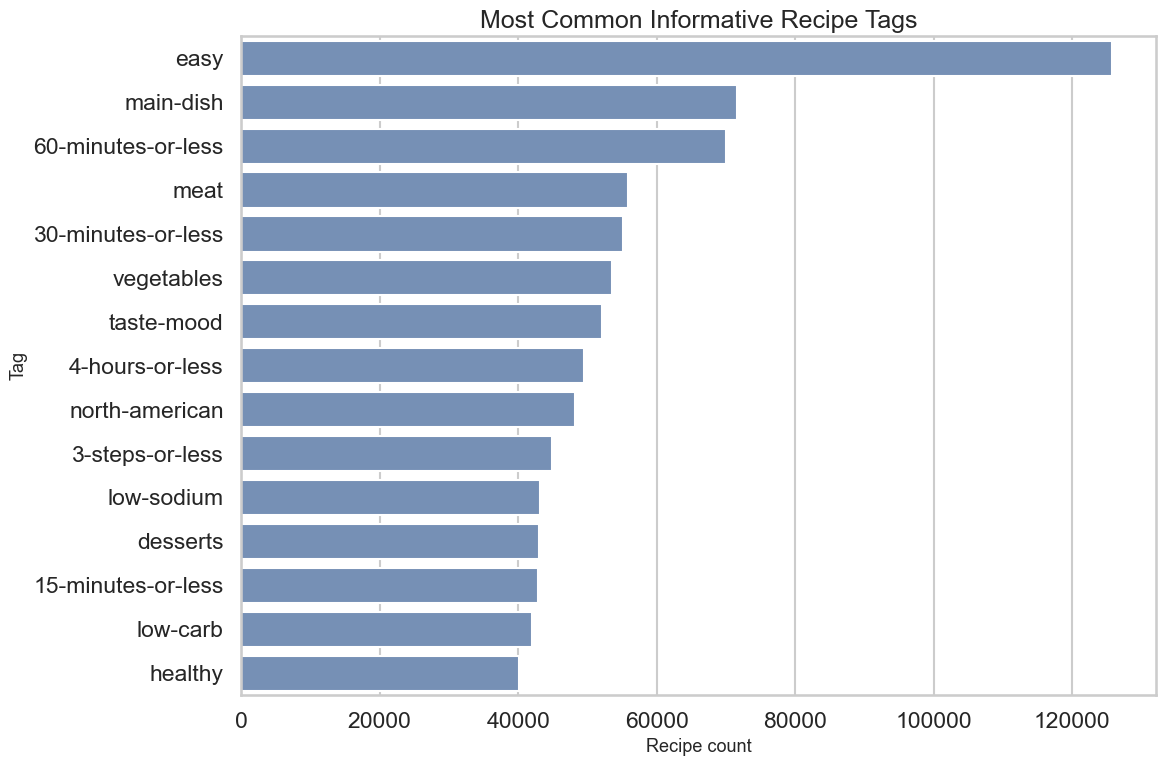

,tag,count
0,easy,125816
1,main-dish,71602
2,60-minutes-or-less,69990
3,meat,55818
4,30-minutes-or-less,55077
5,vegetables,53614
6,taste-mood,52093
7,4-hours-or-less,49497
8,north-american,48214
9,3-steps-or-less,44828


In [8]:
from collections import Counter

generic_tags = {
    "preparation",
    "time-to-make",
    "course",
    "main-ingredient",
    "dietary",
    "occasion",
    "cuisine",
    "low-in-something",
    "equipment",
    "number-of-servings",
}

tag_counter = Counter()
for tags in recipes["tags_list"]:
    tag_counter.update(tag for tag in tags if tag not in generic_tags)

top_tags = pd.DataFrame(tag_counter.most_common(15), columns=["tag", "count"])

plt.figure(figsize=(12, 8))
sns.barplot(data=top_tags, y="tag", x="count", color="#6c8ebf")
plt.title("Most Common Informative Recipe Tags")
plt.xlabel("Recipe count")
plt.ylabel("Tag")
plt.tight_layout()
plt.savefig(figure_dir / "top_informative_tags.png", dpi=200, bbox_inches="tight")
plt.show()

top_tags

In [9]:
top_recipes = (
    recipe_model.loc[recipe_model["rating_count"] > 0, ["id", "name", "minutes", "n_ingredients", "rating_count", "rating_mean"]]
    .sort_values(["rating_count", "rating_mean"], ascending=[False, False])
    .head(10)
    .rename(columns={"id": "recipe_id"})
)

top_recipes

,recipe_id,name,minutes,n_ingredients,rating_count,rating_mean
212797,27208,to die for crock pot roast,545,5,990,4.5707
66356,89204,crock pot chicken with black beans cream cheese,243,5,958,4.4468
62110,39087,creamy cajun chicken pasta,25,12,806,4.8313
573,32204,whatever floats your boat brownies,35,14,806,4.7717
117594,69173,kittencal s italian melt in your mouth meatballs,50,10,728,4.8942
114745,22782,jo mama s world famous spaghetti,80,16,695,4.7094
228176,54257,yes virginia there is a great meatloaf,80,10,653,4.6202
150413,28148,oven fried chicken chimichangas,45,9,621,4.8180
113890,68955,japanese mum s chicken,45,7,620,4.6258
16073,25885,banana banana bread,75,7,618,4.6845


## Numeric Relationships

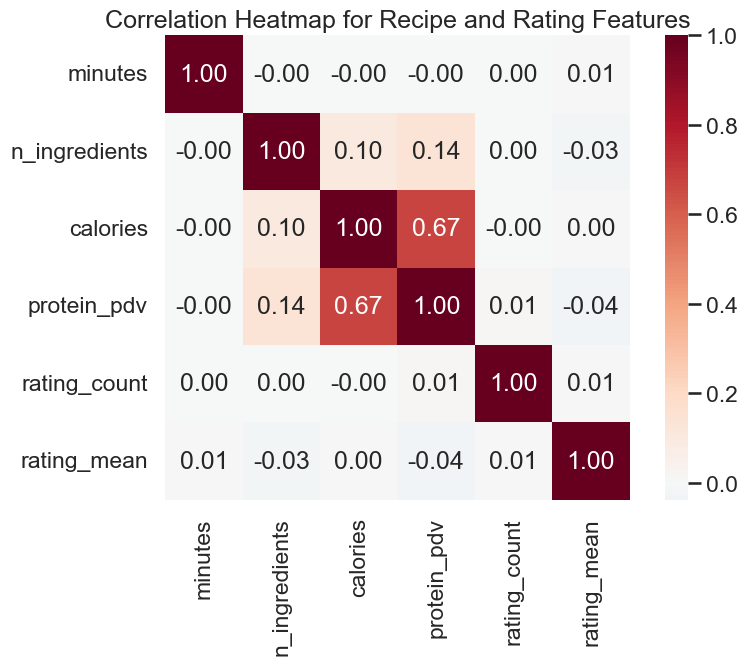

,minutes,n_ingredients,calories,protein_pdv,rating_count,rating_mean
minutes,1.000,-0.001,-0.001,-0.001,0.001,0.005
n_ingredients,-0.001,1.000,0.101,0.139,0.002,-0.026
calories,-0.001,0.101,1.000,0.673,-0.004,0.005
protein_pdv,-0.001,0.139,0.673,1.000,0.014,-0.038
rating_count,0.001,0.002,-0.004,0.014,1.000,0.010
rating_mean,0.005,-0.026,0.005,-0.038,0.010,1.000


In [10]:
corr_cols = ["minutes", "n_ingredients", "calories", "protein_pdv", "rating_count", "rating_mean"]
corr_frame = recipe_model.loc[recipe_model["rating_count"] > 0, corr_cols].corr(numeric_only=True)

plt.figure(figsize=(9, 7))
sns.heatmap(corr_frame, annot=True, cmap="RdBu_r", center=0, fmt=".2f", square=True)
plt.title("Correlation Heatmap for Recipe and Rating Features")
plt.tight_layout()
plt.savefig(figure_dir / "correlation_heatmap.png", dpi=200, bbox_inches="tight")
plt.show()

corr_frame.round(3)

## EDA Takeaways

- The user-item matrix is extremely sparse, which supports the case for a hybrid recommender instead of pure collaborative filtering.
- Ratings are highly skewed toward 5, so ranking metrics such as Precision@K and NDCG@K are more appropriate than only regression-style error metrics.
- Recipe time and calories are both right-skewed, so clipping or log-based visualization is useful during modeling and reporting.
- Informative tags such as `easy`, `main-dish`, `healthy`, and `vegetarian` suggest strong content-based features for cold-start handling.
- Popular recipes exist, but interaction counts are long-tailed, so popularity alone will not capture the full space of user preferences.
